# Phase 1 — Project B: CNN Architecture Intuition

**Goal**: Understand *why* CNNs are designed the way they are. By the end you will be able to answer: how deep should my network be? what filter size? when to use pooling? what is a residual connection actually doing? You will design three CNNs from scratch and explain every choice.

**Dataset**: CIFAR-10 — 60,000 32×32 color images across 10 classes. Small enough to iterate quickly, complex enough that architecture choices matter.

**The central concept**: **Receptive field**. Every design decision in a CNN flows from one question — *how much of the input does each neuron see?* You will calculate this analytically before training anything, and then verify your intuitions experimentally.

**What you will implement**:
- A `ConvBlock` building block
- Three CNN architectures of increasing sophistication
- Receptive field calculator
- Training loop with learning rate scheduling
- Ablation experiments: filter size, depth, skip connections
- Feature map visualizer

**What you will NOT be given**:
- The architecture — you will design it from first principles
- The depth or filter sizes — you will justify each choice
- Any pretrained weights

---
## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
import torchvision.transforms as T

import copy
import time
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

# MPS for MacBook Air, CUDA for Colab, CPU fallback
if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f'Using device: {DEVICE}')

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

Using device: cuda


---
## Section 1 — The key concept: receptive field

Before writing a single layer, you need to understand **receptive field (RF)** — the region of the input image that influences a single output neuron.

**Why it matters**: If your RF never covers the whole image, your network literally cannot use global context to make a decision. For CIFAR-10 (32×32), you need your final conv layer's RF to cover most or all of those 32×32 pixels.

**How RF grows**:
- A single Conv(kernel=3, stride=1) layer: RF = 3
- Stack two: RF = 5 (each layer adds `kernel - 1` to the RF)
- Add a MaxPool(2×2): RF doubles — pooling is the fast way to grow RF
- General formula for a sequence of conv+pool layers:

```
RF_0 = 1   (a single pixel)
After Conv(k, s): RF += (k - 1) * current_stride_product
After Pool(k, s): stride_product *= s

Simplified for Conv(k=3, s=1) + Pool(2,2) blocks:
  Each conv adds 2 to RF (scaled by accumulated stride)
  Each pool(2) doubles the effective stride
```

### ✏️ TASK 1.1 — Implement `compute_receptive_field`

**What this function does**: Given a list of layer specs, computes the receptive field of the final layer.

**Arguments**:
- `layers` (`list[dict]`): each dict has:
  - `'type'`: `'conv'` or `'pool'`
  - `'kernel'`: int, kernel size
  - `'stride'`: int, stride

**Returns**: `int` — receptive field size in input pixels

**Algorithm**:
```
rf = 1              # receptive field starts at 1 pixel
stride_product = 1  # accumulated stride from all previous layers

for each layer in layers:
    rf += (layer['kernel'] - 1) * stride_product
    stride_product *= layer['stride']

return rf
```

> This formula works for both conv and pool layers — they both contribute to RF growth the same way mathematically.

In [2]:
def compute_receptive_field(layers):
    """
    Compute the receptive field of the final layer given a sequence of layers.

    Args:
        layers: list of dicts, each with keys 'type', 'kernel', 'stride'
                e.g. [{'type': 'conv', 'kernel': 3, 'stride': 1},
                       {'type': 'pool', 'kernel': 2, 'stride': 2}]
    Returns:
        int: receptive field size in pixels
    """
    # YOUR CODE HERE
    rf =1
    stride_prodct =1
    for layer in layers:
        rf += (layer['kernel']-1)*stride_prodct
        stride_prodct *= layer['stride']
    return rf


In [3]:
# ── SANITY CHECK 1.1 ───────────────────────────────────────────────────────

# Single 3x3 conv: RF should be 3
rf = compute_receptive_field([{'type': 'conv', 'kernel': 3, 'stride': 1}])
assert rf == 3, f'Expected 3, got {rf}'
print(f'Single 3x3 conv      → RF = {rf}  (expected 3)  ✓')

# Two 3x3 convs: RF should be 5
rf = compute_receptive_field([
    {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'conv', 'kernel': 3, 'stride': 1},
])
assert rf == 5, f'Expected 5, got {rf}'
print(f'Two 3x3 convs        → RF = {rf}  (expected 5)  ✓')

# 3x3 conv + 2x2 pool: RF should be 4
rf = compute_receptive_field([
    {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
])
assert rf == 4, f'Expected 4, got {rf}'
print(f'3x3 conv + 2x2 pool  → RF = {rf}  (expected 4)  ✓')

# 2 conv blocks of (conv3 + conv3 + pool2) — typical shallow CNN
two_block = [
    {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
    {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
]
rf = compute_receptive_field(two_block)
assert rf == 16, f'Expected 16, got {rf}'
print(f'2 blocks (conv+conv+pool) → RF = {rf}  (expected 16)  ✓')

print('\nAll RF sanity checks passed!')

Single 3x3 conv      → RF = 3  (expected 3)  ✓
Two 3x3 convs        → RF = 5  (expected 5)  ✓
3x3 conv + 2x2 pool  → RF = 4  (expected 4)  ✓
2 blocks (conv+conv+pool) → RF = 16  (expected 16)  ✓

All RF sanity checks passed!


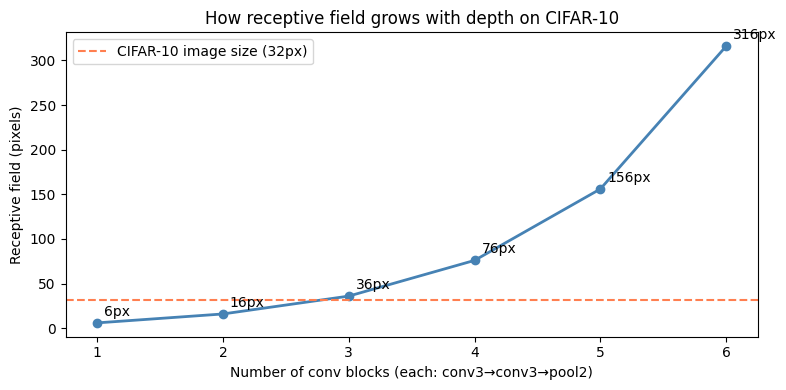

Key question: at what depth does RF first cover the full 32x32 image?
  1 blocks → RF = 6px 
  2 blocks → RF = 16px 
  3 blocks → RF = 36px ← FULL COVERAGE
  4 blocks → RF = 76px ← FULL COVERAGE
  5 blocks → RF = 156px ← FULL COVERAGE
  6 blocks → RF = 316px ← FULL COVERAGE


In [4]:
# ── RF INTUITION: visualize how RF grows with depth ─────────────────────────
# This plot is given to you — study it before designing your architectures.

def rf_after_n_blocks(n_blocks, conv_per_block=2, pool_stride=2):
    """RF after n identical blocks of (conv3 + conv3 + pool2)."""
    layers = []
    for _ in range(n_blocks):
        for _ in range(conv_per_block):
            layers.append({'type': 'conv', 'kernel': 3, 'stride': 1})
        layers.append({'type': 'pool', 'kernel': pool_stride, 'stride': pool_stride})
    return compute_receptive_field(layers)

blocks = list(range(1, 7))
rfs    = [rf_after_n_blocks(b) for b in blocks]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(blocks, rfs, marker='o', color='steelblue', linewidth=2)
ax.axhline(y=32, color='coral', linestyle='--', label='CIFAR-10 image size (32px)')
for b, rf in zip(blocks, rfs):
    ax.annotate(f'{rf}px', (b, rf), textcoords='offset points', xytext=(5, 5), fontsize=10)
ax.set_xlabel('Number of conv blocks (each: conv3→conv3→pool2)')
ax.set_ylabel('Receptive field (pixels)')
ax.set_title('How receptive field grows with depth on CIFAR-10')
ax.legend()
plt.tight_layout()
plt.show()

print('Key question: at what depth does RF first cover the full 32x32 image?')
for b, rf in zip(blocks, rfs):
    print(f'  {b} blocks → RF = {rf}px {"← FULL COVERAGE" if rf >= 32 else ""}')

**Before moving on, answer:**

1. How many blocks do you need before RF covers the full 32×32 image?
2. What happens to spatial resolution after 3 pool(2) operations on a 32×32 image? Calculate it.
3. Why do we use multiple 3×3 convs instead of one large 7×7 conv to achieve the same RF?
   Hint: compare parameter counts. A single 7×7 conv with C channels has how many parameters vs two 3×3 convs?

*(Your answers here)*
1. we need 3 blocks to make RF cover full image.
2. it becomes 4*4 resolution
3. we need 3 3*3 conv to have 7*7 RF, but this block has 27 parameter, where 7*7 kernel needs 49* parameters

---
## Section 2 — Data loading

CIFAR-10 is built into torchvision — no manual download needed.

In [5]:
# ── Data augmentation for training ─────────────────────────────────────────
# These transforms are standard for CIFAR-10. Study each one:
#   RandomHorizontalFlip: a cat facing left is still a cat
#   RandomCrop(32, padding=4): slight translation invariance
#   Normalize: centers each channel around 0, std ~1 (helps optimizer)

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomCrop(32, padding=4),
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=train_transform)
val_dataset   = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transform)

# change to num_workers = 0 and pin_memory = False if using mps
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Val samples   : {len(val_dataset):,}')
print(f'Input shape   : {train_dataset[0][0].shape}  (C, H, W)')
print(f'Num classes   : {len(CIFAR10_CLASSES)}')

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


Train samples : 50,000
Val samples   : 10,000
Input shape   : torch.Size([3, 32, 32])  (C, H, W)
Num classes   : 10


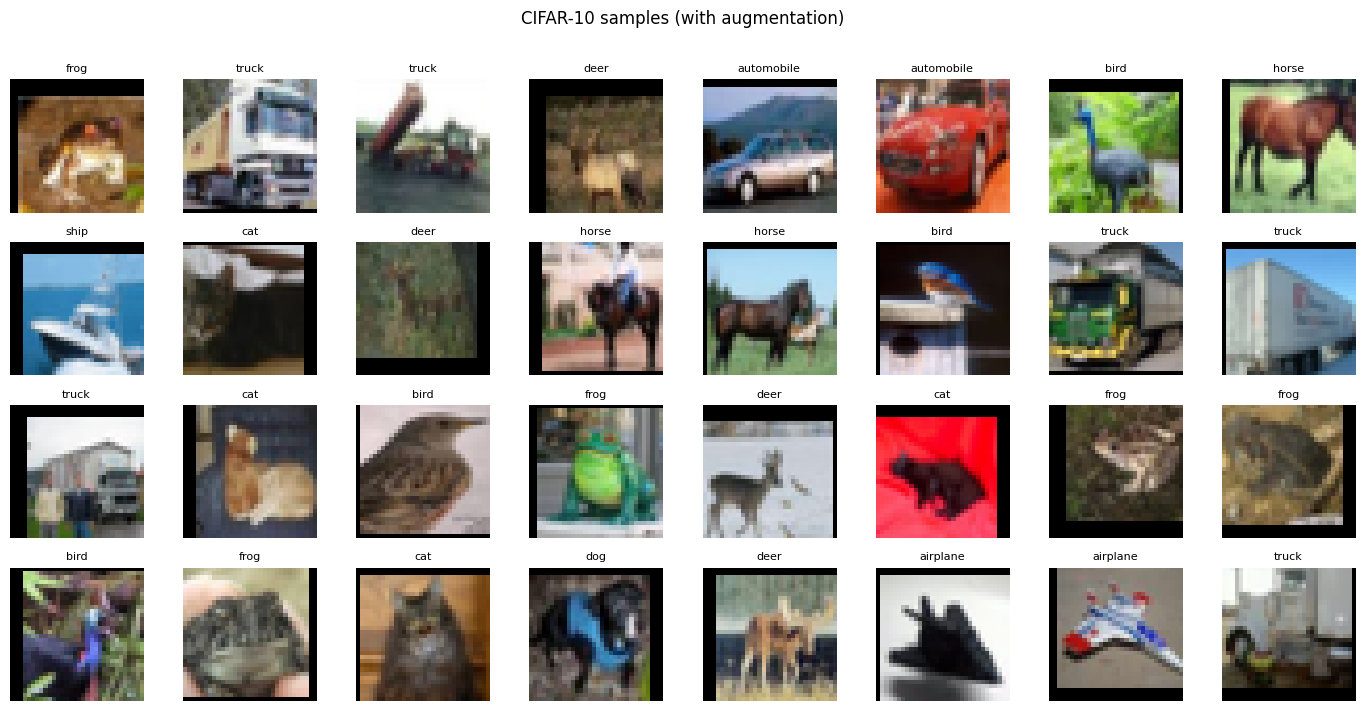

In [6]:
# ── Visualize some training samples ────────────────────────────────────────
def denormalize(tensor, mean=CIFAR_MEAN, std=CIFAR_STD):
    """Reverse normalization for display."""
    t = tensor.clone()
    for c, (m, s) in enumerate(zip(mean, std)):
        t[c] = t[c] * s + m
    return t.clamp(0, 1)

fig, axes = plt.subplots(4, 8, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(denormalize(img).permute(1, 2, 0).numpy())
    ax.set_title(CIFAR10_CLASSES[label], fontsize=8)
    ax.axis('off')
plt.suptitle('CIFAR-10 samples (with augmentation)', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 3 — Building blocks

Good CNN code is modular — you build small blocks and stack them. This section has two building blocks: `ConvBlock` and `ResidualBlock`.

### ✏️ TASK 3.1 — Implement `ConvBlock`

**What this does**: One unit of conv → batchnorm → activation → optional dropout. This is the standard repeating unit in modern CNNs.

**Arguments to `__init__`**:
- `in_channels` (`int`): input channel count
- `out_channels` (`int`): output channel count
- `kernel_size` (`int`): default 3
- `stride` (`int`): default 1
- `padding` (`int`): default 1. With kernel=3, padding=1 keeps spatial size the same when stride=1.
- `dropout` (`float`): default 0.0

**Architecture**:
```
Conv2d(in_channels, out_channels, kernel_size, stride, padding, bias=False)
  ↓
BatchNorm2d(out_channels)   ← always use BN after conv (unlike MLP where it was optional)
  ↓
ReLU()
  ↓
Dropout2d(p=dropout)        ← only if dropout > 0
```

> **Why `bias=False` when using BatchNorm?** BatchNorm already learns a bias term (β). Adding a second learnable bias in Conv2d is redundant and wastes parameters.

> **Why BatchNorm before ReLU?** This is a design debate in the field — original ResNet does BN→ReLU, some papers argue ReLU→BN. For this project, follow the original convention: BN first.

In [7]:
class ConvBlock(nn.Module):
    """
    Standard conv block: Conv2d → BatchNorm2d → ReLU → [Dropout2d]

    Args:
        in_channels  (int): input channels
        out_channels (int): output channels
        kernel_size  (int): conv kernel size, default 3
        stride       (int): conv stride, default 1
        padding      (int): conv padding, default 1
        dropout      (float): Dropout2d probability, default 0.0
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        self.model = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size,stride,padding,bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        # YOUR CODE HERE
        return self.model(x)

In [8]:
# ── SANITY CHECK 3.1 ───────────────────────────────────────────────────────
block = ConvBlock(3, 32, kernel_size=3, padding=1)
x     = torch.randn(8, 3, 32, 32)   # batch of 8 CIFAR images
out   = block(x)

assert out.shape == (8, 32, 32, 32), f'Expected (8,32,32,32), got {out.shape}'
print(f'ConvBlock output shape: {out.shape}  (B, C_out, H, W)  ✓')

# With stride=2, spatial dims should halve
block_s2 = ConvBlock(3, 32, kernel_size=3, stride=2, padding=1)
out_s2   = block_s2(x)
assert out_s2.shape == (8, 32, 16, 16), f'Expected (8,32,16,16), got {out_s2.shape}'
print(f'ConvBlock stride=2:     {out_s2.shape}  (spatial halved)  ✓')

# With dropout
block_drop = ConvBlock(3, 32, dropout=0.2)
block_drop.train()
out_drop = block_drop(x)
assert out_drop.shape == (8, 32, 32, 32)
print(f'ConvBlock with dropout: {out_drop.shape}  ✓')

# bias=False check — conv should have no bias parameter
conv_layer = [m for m in block.modules() if isinstance(m, nn.Conv2d)][0]
assert conv_layer.bias is None, 'Conv2d should have bias=False when using BatchNorm'
print(f'Conv bias is None (correct — BN handles bias)  ✓')

print('\nAll ConvBlock sanity checks passed!')

ConvBlock output shape: torch.Size([8, 32, 32, 32])  (B, C_out, H, W)  ✓
ConvBlock stride=2:     torch.Size([8, 32, 16, 16])  (spatial halved)  ✓
ConvBlock with dropout: torch.Size([8, 32, 32, 32])  ✓
Conv bias is None (correct — BN handles bias)  ✓

All ConvBlock sanity checks passed!


### ✏️ TASK 3.2 — Implement `ResidualBlock`

**What this does**: A residual block from ResNet. The key idea: instead of learning `H(x)`, learn the *residual* `F(x) = H(x) - x`, so the full output is `F(x) + x`. This skip connection lets gradients flow directly to early layers and makes training much deeper networks possible.

**Arguments to `__init__`**:
- `channels` (`int`): both input and output channel count (keep them the same for simplicity)
- `dropout` (`float`): default 0.0

**Architecture**:
```
input x
  ↓
ConvBlock(channels, channels, kernel_size=3, padding=1)   ← conv1
  ↓
Conv2d(channels, channels, kernel_size=3, padding=1, bias=False)  ← conv2 (no activation yet)
BatchNorm2d(channels)
  ↓
add skip connection: output = ReLU(above + x)   ← the residual addition
  ↓
[Dropout2d if dropout > 0]
```

**Forward pseudocode**:
```
residual = x                    # save input
out = self.conv1(x)             # first conv block (conv+bn+relu)
out = self.bn2(self.conv2(out)) # second conv+bn (no relu yet)
out = F.relu(out + residual)    # add skip, then activate
if self.dropout: out = self.dropout(out)
return out
```

> **Why ReLU *after* the addition?** The skip connection should be able to pass gradients with zero modification. If you put ReLU before adding, you've potentially zeroed some values in the skip path. ReLU after addition is the standard ResNet design.

In [9]:
class ResidualBlock(nn.Module):
    """
    Basic residual block: two conv layers with a skip connection.
    Input and output have the same shape.

    Args:
        channels (int):   number of input AND output channels
        dropout  (float): Dropout2d probability, default 0.0
    """
    def __init__(self, channels, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        self.blocks=nn.Sequential(
            nn.Conv2d(channels,channels,3,1,1,bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels,channels,3,1,1,bias=False),
            nn.BatchNorm2d(channels),
        )


    def forward(self, x):
        # YOUR CODE HERE
        out = F.relu(self.blocks(x)+x)
        return out

In [10]:
# ── SANITY CHECK 3.2 ───────────────────────────────────────────────────────
res_block = ResidualBlock(channels=64)
x         = torch.randn(8, 64, 16, 16)
out       = res_block(x)

# Output shape must equal input shape — this is required for the skip connection
assert out.shape == x.shape, f'ResidualBlock must preserve shape. Got {out.shape}, expected {x.shape}'
print(f'ResidualBlock output shape: {out.shape}  (same as input)  ✓')

# Verify the skip connection is actually working:
# Zero out the conv weights → output should equal ReLU(x) not zeros
res_block_test = ResidualBlock(channels=4)
for p in res_block_test.parameters():
    p.data.zero_()
x_small = torch.randn(2, 4, 8, 8)
out_test = res_block_test(x_small)
expected = F.relu(x_small)  # with zero conv weights, output = relu(0 + x) = relu(x)
assert torch.allclose(out_test, expected, atol=1e-5), 'Skip connection not working correctly'
print(f'Skip connection verified (zeroed conv weights → output = relu(x))  ✓')

print('\nAll ResidualBlock sanity checks passed!')

ResidualBlock output shape: torch.Size([8, 64, 16, 16])  (same as input)  ✓
Skip connection verified (zeroed conv weights → output = relu(x))  ✓

All ResidualBlock sanity checks passed!


---
## Section 4 — Three CNN architectures

You will implement three architectures of increasing sophistication. Before writing any code, **fill in the design table** for each one.

### Architecture design worksheet

For each architecture, the spatial resolution after each block is given. Your job is to fill in the RF and reason about it.

| Architecture | Blocks | Final RF | Covers 32×32? | Expected accuracy |
|---|---|---|---|---|
| Shallow CNN | 2 conv blocks | 16 | no | ~75% |
| Deep CNN | 3 conv blocks | 36 | yes | ~83% |
| ResNet-style | 3 stages + residual | 38 | yes | ~88% |

*(Fill in your RF calculations before implementing. Use `compute_receptive_field`.)*

---
### ✏️ TASK 4.1 — Implement `ShallowCNN`

**Goal**: A baseline — the simplest CNN that achieves reasonable accuracy.

**Architecture spec**:
```
Input: (B, 3, 32, 32)

Block 1:
  ConvBlock(3,  32, kernel=3, padding=1)   → (B, 32, 32, 32)
  ConvBlock(32, 32, kernel=3, padding=1)   → (B, 32, 32, 32)
  MaxPool2d(2, 2)                          → (B, 32, 16, 16)

Block 2:
  ConvBlock(32, 64, kernel=3, padding=1)   → (B, 64, 16, 16)
  ConvBlock(64, 64, kernel=3, padding=1)   → (B, 64, 16, 16)
  MaxPool2d(2, 2)                          → (B, 64,  8,  8)

Classifier head:
  AdaptiveAvgPool2d(1)                     → (B, 64,  1,  1)
  Flatten                                  → (B, 64)
  Linear(64, num_classes)
```

> **Why `AdaptiveAvgPool2d(1)` at the end?** This is global average pooling — it collapses each feature map to a single number by averaging all spatial positions. It replaces the old style of `Flatten → Linear(64*8*8, hidden)` which wastes many parameters and assumes a fixed input size. GAP is input-size agnostic and strongly regularizing.

In [11]:
class ShallowCNN(nn.Module):
    """
    2-block CNN for CIFAR-10. Baseline architecture.

    Args:
        num_classes (int): number of output classes, default 10
        dropout     (float): dropout in ConvBlocks, default 0.0
    """
    def __init__(self, num_classes=10, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        # Build self.features (the conv blocks) and self.classifier (the head)
        # as separate nn.Sequential objects — this makes visualization easier later
        self.features = nn.Sequential(
            ConvBlock(3,32,kernel_size=3,stride=1,padding=1,dropout=dropout),
            ConvBlock(32,32,kernel_size=3,stride=1,padding=1,dropout=dropout),
            nn.MaxPool2d(2,2),

            ConvBlock(32,64,kernel_size=3,stride=1,padding=1,dropout=dropout),
            ConvBlock(64,64,kernel_size=3,stride=1,padding=1,dropout=dropout),
            nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64,num_classes),
        )

    def forward(self, x):
        # YOUR CODE HERE
        x = self.features(x)
        return self.classifier(x)

In [12]:
# ── SANITY CHECK 4.1 ───────────────────────────────────────────────────────
model = ShallowCNN(num_classes=10)
x     = torch.randn(8, 3, 32, 32)
out   = model(x)

assert out.shape == (8, 10), f'Expected (8, 10), got {out.shape}'
print(f'ShallowCNN output shape: {out.shape}  ✓')

n_params = sum(p.numel() for p in model.parameters())
print(f'ShallowCNN parameters: {n_params:,}  (expect ~100K–200K)')
assert 50_000 < n_params < 500_000, f'Parameter count seems off: {n_params}'

# RF calculation for ShallowCNN — does it cover 32x32?
shallow_layers = [
    {'type': 'conv', 'kernel': 3, 'stride': 1},  # block1 conv1
    {'type': 'conv', 'kernel': 3, 'stride': 1},  # block1 conv2
    {'type': 'pool', 'kernel': 2, 'stride': 2},  # block1 pool
    {'type': 'conv', 'kernel': 3, 'stride': 1},  # block2 conv1
    {'type': 'conv', 'kernel': 3, 'stride': 1},  # block2 conv2
    {'type': 'pool', 'kernel': 2, 'stride': 2},  # block2 pool
]
rf = compute_receptive_field(shallow_layers)
print(f'ShallowCNN receptive field: {rf}px  (image is 32px — {"COVERED" if rf >= 32 else "NOT fully covered"})  ✓')
print('\nAll ShallowCNN sanity checks passed!')

ShallowCNN output shape: torch.Size([8, 10])  ✓
ShallowCNN parameters: 66,410  (expect ~100K–200K)
ShallowCNN receptive field: 16px  (image is 32px — NOT fully covered)  ✓

All ShallowCNN sanity checks passed!


### ✏️ TASK 4.2 — Implement `DeepCNN`

**Goal**: Add a third stage and double the channel count. This is where you'll first see the pattern of *doubling channels while halving spatial resolution* — the core design principle of VGG, ResNet, EfficientNet, and nearly every modern CNN.

**Architecture spec**:
```
Input: (B, 3, 32, 32)

Stage 1:
  ConvBlock(3,  64, ...)   → (B,  64, 32, 32)
  ConvBlock(64, 64, ...)   → (B,  64, 32, 32)
  MaxPool2d(2, 2)          → (B,  64, 16, 16)

Stage 2:
  ConvBlock(64,  128, ...) → (B, 128, 16, 16)
  ConvBlock(128, 128, ...) → (B, 128, 16, 16)
  MaxPool2d(2, 2)          → (B, 128,  8,  8)

Stage 3:
  ConvBlock(128, 256, ...) → (B, 256,  8,  8)
  ConvBlock(256, 256, ...) → (B, 256,  8,  8)
  MaxPool2d(2, 2)          → (B, 256,  4,  4)

Head:
  AdaptiveAvgPool2d(1)     → (B, 256, 1, 1)
  Flatten                  → (B, 256)
  Dropout(p)               ← dropout on the flattened features
  Linear(256, num_classes)
```

> **Why double channels at each stage?** Spatial resolution halves with each pool, so each feature map covers 4× more input area. To compensate — to keep the representational capacity constant per spatial position — you double the number of channels. This is the core capacity-preservation principle behind the design of VGG, ResNet, and most modern CNNs.

**New argument**: `dropout` (`float`) — apply `Dropout(p)` before the final linear layer (not Dropout2d here — we're in the flattened space).

In [13]:
class DeepCNN(nn.Module):
    """
    3-stage CNN. Channels double (64→128→256) as spatial dims halve.

    Args:
        num_classes (int): default 10
        dropout     (float): applied before final linear layer, default 0.0
    """
    def __init__(self, num_classes=10, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        self.features = nn.Sequential(
            ConvBlock(3,64,kernel_size=3,stride=1,padding=1,dropout=dropout),
            ConvBlock(64,64,kernel_size=3,stride=1,padding=1,dropout=dropout),
            nn.MaxPool2d(2,2),

            ConvBlock(64,128,kernel_size=3,stride=1,padding=1,dropout=dropout),
            ConvBlock(128,128,kernel_size=3,stride=1,padding=1,dropout=dropout),
            nn.MaxPool2d(2,2),

            ConvBlock(128,256,kernel_size=3,stride=1,padding=1,dropout=dropout),
            ConvBlock(256,256,kernel_size=3,stride=1,padding=1,dropout=dropout),
            nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout2d(dropout),
            nn.Linear(256,num_classes),
        )

    def forward(self, x):
        # YOUR CODE HERE
        x = self.features(x)
        return self.classifier(x)

In [14]:
# ── SANITY CHECK 4.2 ───────────────────────────────────────────────────────
model = DeepCNN(num_classes=10, dropout=0.3)
x     = torch.randn(8, 3, 32, 32)
out   = model(x)

assert out.shape == (8, 10), f'Expected (8, 10), got {out.shape}'
print(f'DeepCNN output shape: {out.shape}  ✓')

n_params = sum(p.numel() for p in model.parameters())
print(f'DeepCNN parameters: {n_params:,}  (expect ~1M–3M)')
assert 500_000 < n_params < 10_000_000, f'Parameter count seems off: {n_params}'

deep_layers = [
    {'type': 'conv', 'kernel': 3, 'stride': 1}, {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
    {'type': 'conv', 'kernel': 3, 'stride': 1}, {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
    {'type': 'conv', 'kernel': 3, 'stride': 1}, {'type': 'conv', 'kernel': 3, 'stride': 1},
    {'type': 'pool', 'kernel': 2, 'stride': 2},
]
rf = compute_receptive_field(deep_layers)
print(f'DeepCNN receptive field: {rf}px  ({"FULL COVERAGE" if rf >= 32 else "not full"})  ✓')
print('\nAll DeepCNN sanity checks passed!')

DeepCNN output shape: torch.Size([8, 10])  ✓
DeepCNN parameters: 1,148,874  (expect ~1M–3M)
DeepCNN receptive field: 36px  (FULL COVERAGE)  ✓

All DeepCNN sanity checks passed!


### ✏️ TASK 4.3 — Implement `ResNetStyle`

**Goal**: Add residual connections between stages. This introduces skip connections that allow much deeper training and are the core innovation of ResNet (He et al., 2015).

**Architecture spec**:
```
Input: (B, 3, 32, 32)

Stem:
  ConvBlock(3, 64, kernel=3, padding=1)       → (B, 64, 32, 32)

Stage 1 (64 channels):
  ResidualBlock(64)                           → (B, 64, 32, 32)
  ResidualBlock(64)                           → (B, 64, 32, 32)
  ConvBlock(64, 128, stride=2, padding=1)     → (B, 128, 16, 16)  ← stride=2 to downsample

Stage 2 (128 channels):
  ResidualBlock(128)                          → (B, 128, 16, 16)
  ResidualBlock(128)                          → (B, 128, 16, 16)
  ConvBlock(128, 256, stride=2, padding=1)    → (B, 256,  8,  8)

Stage 3 (256 channels):
  ResidualBlock(256)                          → (B, 256,  8,  8)
  ResidualBlock(256)                          → (B, 256,  8,  8)

Head:
  AdaptiveAvgPool2d(1)    → (B, 256, 1, 1)
  Flatten                 → (B, 256)
  Dropout(p)
  Linear(256, num_classes)
```

> **Note**: We use `ConvBlock(..., stride=2)` instead of MaxPool for downsampling here. This is the modern ResNet convention — learned downsampling via strided conv rather than fixed maxpool.

In [15]:
class ResNetStyle(nn.Module):
    """
    ResNet-style CNN with residual blocks.

    Args:
        num_classes (int): default 10
        dropout     (float): applied before final linear, default 0.0
    """
    def __init__(self, num_classes=10, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        self.features = nn.Sequential(
            ConvBlock(3,64,kernel_size=3,stride=1,padding=1,dropout=dropout),

            ResidualBlock(64,dropout=dropout),
            ResidualBlock(64,dropout=dropout),
            ConvBlock(64,128,kernel_size=3,stride=2,padding=1,dropout=dropout),

            ResidualBlock(128,dropout=dropout),
            ResidualBlock(128,dropout=dropout),
            ConvBlock(128,256,kernel_size=3,stride=2,padding=1,dropout=dropout),

            ResidualBlock(256,dropout=dropout),
            ResidualBlock(256,dropout=dropout),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256,num_classes),
        )

    def forward(self, x):
        # YOUR CODE HERE
        x = self.features(x)
        return self.classifier(x)

In [16]:
# ── SANITY CHECK 4.3 ───────────────────────────────────────────────────────
model = ResNetStyle(num_classes=10, dropout=0.2)
x     = torch.randn(8, 3, 32, 32)
out   = model(x)

assert out.shape == (8, 10), f'Expected (8,10), got {out.shape}'
print(f'ResNetStyle output shape: {out.shape}  ✓')

n_params = sum(p.numel() for p in model.parameters())
print(f'ResNetStyle parameters: {n_params:,}')

# Gradient flow test — gradients should reach the first layer
out.mean().backward()
first_conv = [m for m in model.modules() if isinstance(m, nn.Conv2d)][0]
assert first_conv.weight.grad is not None, 'No gradient at first conv layer!'
grad_norm = first_conv.weight.grad.norm().item()
assert grad_norm > 0, 'Gradient is zero at first layer — skip connections may be broken'
print(f'Gradient at first conv layer: norm = {grad_norm:.6f}  ✓')

print('\nAll ResNetStyle sanity checks passed!')

ResNetStyle output shape: torch.Size([8, 10])  ✓
ResNetStyle parameters: 3,473,994
Gradient at first conv layer: norm = 0.241498  ✓

All ResNetStyle sanity checks passed!


---
## Section 5 — Training infrastructure

### ✏️ TASK 5.1 — Implement `train_one_epoch` and `evaluate`

These follow the same pattern as Project A, but now with **accuracy** as the primary metric and a **learning rate scheduler**.

**`train_one_epoch` arguments**:
- `model`, `loader`, `optimizer`, `criterion`, `device` — same as before
- `scheduler` (optional): call `scheduler.step()` after each batch if provided

**Returns**: `(train_loss: float, train_acc: float)`

**`evaluate` arguments**: `model`, `loader`, `criterion`, `device`

**Returns**: `(val_loss: float, val_acc: float)`

**Accuracy calculation**:
```
logits = model(x)                            # shape (B, num_classes)
preds  = logits.argmax(dim=1)                # shape (B,) — predicted class index
correct += (preds == labels).sum().item()
total   += labels.size(0)
accuracy = correct / total
```

In [17]:
def train_one_epoch(model, loader, optimizer, criterion, device, scheduler=None):
    """
    One training epoch for classification.

    Returns:
        (train_loss, train_acc): both floats
    """
    # YOUR CODE HERE
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    for X_batch,y_batch in loader:
        X_batch,y_batch = X_batch.to(device),y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += X_batch.size(0)
        loss = criterion(logits,y_batch)
        loss.backward()
        optimizer.step()
        # if scheduler is not None:
        #     scheduler.step() #instruction is wrong here, step every epoch, not batch
        total_loss += loss.item()
    return total_loss/len(loader), correct/total



def evaluate(model, loader, criterion, device):
    """
    Evaluate model on a DataLoader.

    Returns:
        (val_loss, val_acc): both floats
    """
    # YOUR CODE HERE
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch,y_batch in loader:
            X_batch,y_batch = X_batch.to(device),y_batch.to(device)
            logits = model(X_batch)
            preds = logits.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total += X_batch.size(0)
            loss = criterion(logits,y_batch)
            total_loss += loss.item()
    return total_loss/len(loader), correct/total

### ✏️ TASK 5.2 — Implement `train_model`

**New additions vs Project A**:
- Use `nn.CrossEntropyLoss()` (classification, not MSE)
- Add a **cosine annealing LR scheduler**: `torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)`. This gradually reduces LR following a cosine curve — smoother and usually better than step decay.
- Track `val_acc` instead of RMSLE for early stopping

**Arguments**:
- `model` (`nn.Module`): already instantiated model
- `train_loader`, `val_loader` (`DataLoader`)
- `config` (`dict`):
  ```python
  config = {
      'lr'          : 1e-3,
      'weight_decay': 1e-4,
      'epochs'      : 50,
      'patience'    : 15,
  }
  ```
- `device`

**Returns**: `dict` with keys:
- `'model'`: best model (highest val acc)
- `'train_losses'`, `'val_losses'`, `'train_accs'`, `'val_accs'`: lists
- `'best_val_acc'`: float
- `'lr_history'`: list of LR values per epoch (for plotting)

In [18]:
def train_model(model, train_loader, val_loader, config, device):
    """
    Full training loop for classification with cosine LR schedule.

    Returns:
        dict: {'model', 'train_losses', 'val_losses', 'train_accs',
               'val_accs', 'best_val_acc', 'lr_history'}
    """
    # YOUR CODE HERE
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(),lr = config['lr'],weight_decay=config['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=config['epochs'])
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    lr_history = []
    best_val_acc = 0
    current_patience = 0
    for epoch in range(config['epochs']):
        train_loss,train_acc = train_one_epoch(model,train_loader,optimizer,criterion,device)
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_loss,val_acc = evaluate(model,val_loader,criterion,device)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f"epoch {epoch+1} ,val loss is {val_loss:.4f}, val acc is {val_acc}")
        lr_history.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_weights = copy.deepcopy(model.state_dict())
            current_patience = 0
        else:
            current_patience +=1
        if current_patience >= config['patience']:
            print(f"at epoch{epoch+1}, early stopping")
            break
    model.load_state_dict(best_model_weights)
    return {'model':model, 'train_losses':train_losses, 'val_losses':val_losses, 'train_accs':train_accs,
               'val_accs':val_accs, 'best_val_acc':best_val_acc, 'lr_history':lr_history}

In [19]:
# ── SANITY CHECK 5.1–5.2 ──────────────────────────────────────────────────
# Quick 3-epoch run to verify the pipeline works

check_model  = ShallowCNN(num_classes=10).to(DEVICE)
check_config = {'lr': 1e-3, 'weight_decay': 1e-4, 'epochs': 3, 'patience': 5}

check_result = train_model(check_model, train_loader, val_loader, check_config, DEVICE)

assert 'best_val_acc' in check_result
assert len(check_result['train_accs']) == 3
assert 0.0 < check_result['best_val_acc'] < 1.0

# After 3 epochs, accuracy should be at least 20% (random = 10%)
assert check_result['best_val_acc'] > 0.20, \
    f'Accuracy {check_result["best_val_acc"]:.2%} is suspiciously low — check your training loop'

print(f'3-epoch val accuracy: {check_result["best_val_acc"]:.2%}  (expect > 20%)  ✓')
print(f'LR history: {[f"{lr:.5f}" for lr in check_result["lr_history"]]}')
print('\nAll training sanity checks passed!')

epoch 1 ,val loss is 1.4904, val acc is 0.4586
epoch 2 ,val loss is 1.1350, val acc is 0.5906
epoch 3 ,val loss is 1.0906, val acc is 0.618
3-epoch val accuracy: 61.80%  (expect > 20%)  ✓
LR history: ['0.00100', '0.00075', '0.00025']

All training sanity checks passed!


---
## Section 6 — Train and compare all three architectures

Now train all three models with the same config and compare them head-to-head.

In [20]:
# ── Full training config ───────────────────────────────────────────────────
# 50 epochs is enough to see clear differences. On MPS this takes ~15 min total.

TRAIN_CONFIG = {
    'lr'          : 1e-3,
    'weight_decay': 1e-4,
    'epochs'      : 50,
    'patience'    : 15,
}

results = {}

for name, model_cls, kwargs in [
    ('Shallow', ShallowCNN,  {'dropout': 0.0}),
    ('Deep',    DeepCNN,     {'dropout': 0.3}),
    ('ResNet',  ResNetStyle, {'dropout': 0.2}),
]:
    print(f'\n--- Training {name} ---')
    model = model_cls(**kwargs).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    print(f'Parameters: {n_params:,}')

    t0 = time.time()
    result = train_model(model, train_loader, val_loader, TRAIN_CONFIG, DEVICE)
    elapsed = time.time() - t0

    results[name] = result
    print(f'Best val accuracy: {result["best_val_acc"]:.2%}')
    print(f'Trained {len(result["train_accs"])} epochs in {elapsed/60:.1f} min')


--- Training Shallow ---
Parameters: 66,410
epoch 1 ,val loss is 1.3298, val acc is 0.5094
epoch 2 ,val loss is 1.1188, val acc is 0.6018
epoch 3 ,val loss is 1.4355, val acc is 0.5173
epoch 4 ,val loss is 1.3262, val acc is 0.5612
epoch 5 ,val loss is 0.9824, val acc is 0.6561
epoch 6 ,val loss is 0.8799, val acc is 0.6921
epoch 7 ,val loss is 1.0250, val acc is 0.6524
epoch 8 ,val loss is 0.9697, val acc is 0.6638
epoch 9 ,val loss is 0.9118, val acc is 0.6816
epoch 10 ,val loss is 0.9294, val acc is 0.6819
epoch 11 ,val loss is 0.9537, val acc is 0.6721
epoch 12 ,val loss is 0.8360, val acc is 0.7112
epoch 13 ,val loss is 0.8197, val acc is 0.7223
epoch 14 ,val loss is 0.9204, val acc is 0.6864
epoch 15 ,val loss is 0.7600, val acc is 0.7403
epoch 16 ,val loss is 0.8074, val acc is 0.7325
epoch 17 ,val loss is 0.6885, val acc is 0.7651
epoch 18 ,val loss is 0.7411, val acc is 0.7458
epoch 19 ,val loss is 0.8299, val acc is 0.7191
epoch 20 ,val loss is 0.7279, val acc is 0.755
epoch

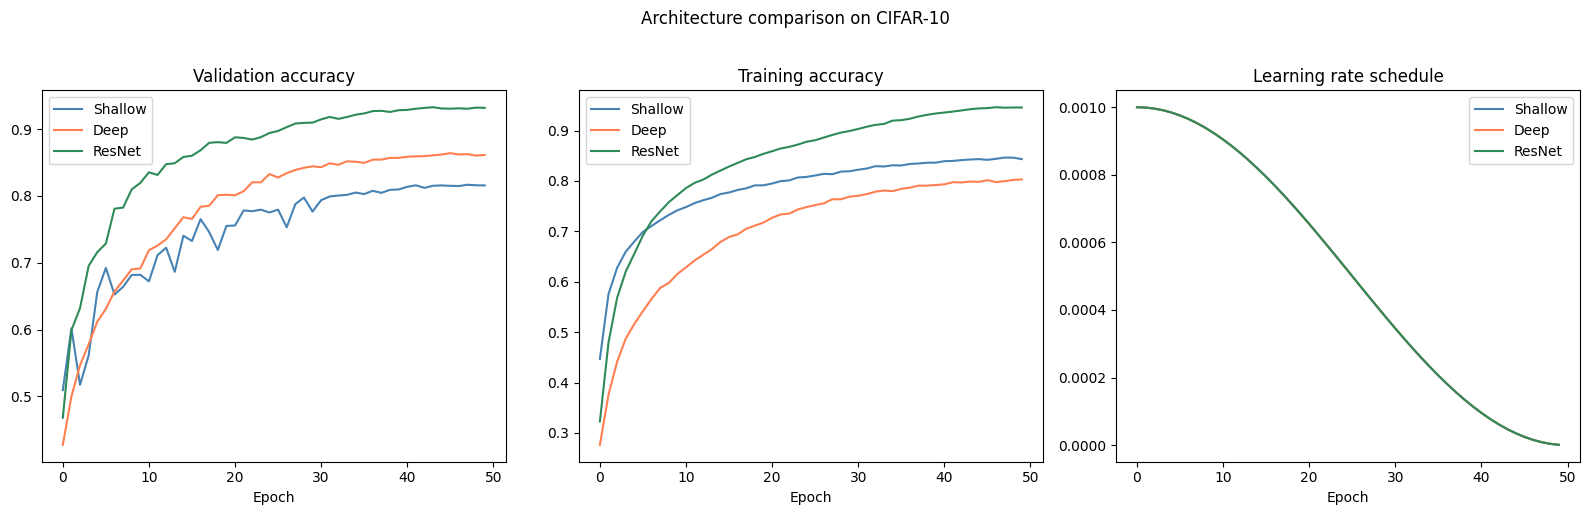


--- Final results ---
Shallow   : val_acc = 81.66%,  train-val gap = 2.78%  (gap > 10% suggests overfitting)
Deep      : val_acc = 86.39%,  train-val gap = -5.80%  (gap > 10% suggests overfitting)
ResNet    : val_acc = 93.26%,  train-val gap = 1.42%  (gap > 10% suggests overfitting)


In [21]:
# ── Comparison plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'Shallow': 'steelblue', 'Deep': 'coral', 'ResNet': 'seagreen'}

for name, result in results.items():
    axes[0].plot(result['val_accs'],   label=name, color=colors[name])
    axes[1].plot(result['train_accs'], label=name, color=colors[name])
    axes[2].plot(result['lr_history'], label=name, color=colors[name])

axes[0].set_title('Validation accuracy')
axes[1].set_title('Training accuracy')
axes[2].set_title('Learning rate schedule')

for ax in axes:
    ax.set_xlabel('Epoch')
    ax.legend()

plt.suptitle('Architecture comparison on CIFAR-10', y=1.02)
plt.tight_layout()
plt.show()

# Summary table
print('\n--- Final results ---')
for name, result in results.items():
    gap = result['train_accs'][-1] - result['val_accs'][-1]
    print(f'{name:10s}: val_acc = {result["best_val_acc"]:.2%},  '
          f'train-val gap = {gap:.2%}  '
          f'(gap > 10% suggests overfitting)')

**After running, answer:**

1. Which architecture had the highest validation accuracy? Was it also the most overfit (largest train-val gap)?<br>
The ResNet get the highest val_accuracy and the shallow one overfit
2. Did the residual connections visibly help? In what way — higher final accuracy, faster convergence, or both?<br>
Yes, the residual connections help a lot. with higher accuracy
3. Look at the training accuracy curves — did any model converge faster than others? What does that tell you?<br>
they converge almost at the same epoch, because they share same learning rate scheduler.

*(Your answers here)*

---
## Section 7 — Ablation: filter size (3×3 vs 5×5 vs 1×1)

### ✏️ TASK 7.1 — Implement `DeepCNN_CustomKernel`

A copy of `DeepCNN` but with a configurable `kernel_size` argument passed to every `ConvBlock`. Everything else stays the same.

**Key detail**: when `kernel_size=5`, you need `padding=2` to preserve spatial size. When `kernel_size=1`, `padding=0`. The general rule is `padding = kernel_size // 2`.

**Arguments**: same as `DeepCNN` plus `kernel_size` (`int`, default 3).

In [22]:
class DeepCNN_CustomKernel(nn.Module):
    """
    DeepCNN with configurable kernel size for ablation study.

    Args:
        num_classes (int): default 10
        dropout     (float): default 0.0
        kernel_size (int): kernel size for all ConvBlocks, default 3
    """
    def __init__(self, num_classes=10, dropout=0.0, kernel_size=3):
        super().__init__()
        # Hint: padding = kernel_size // 2 keeps spatial size unchanged
        # YOUR CODE HERE
        padding = kernel_size // 2
        self.features = nn.Sequential(
            ConvBlock(3,64,kernel_size=kernel_size,stride=1,padding=padding,dropout=dropout),
            ConvBlock(64,64,kernel_size=kernel_size,stride=1,padding=padding,dropout=dropout),
            nn.MaxPool2d(2,2),

            ConvBlock(64,128,kernel_size=kernel_size,stride=1,padding=padding,dropout=dropout),
            ConvBlock(128,128,kernel_size=kernel_size,stride=1,padding=padding,dropout=dropout),
            nn.MaxPool2d(2,2),

            ConvBlock(128,256,kernel_size=kernel_size,stride=1,padding=padding,dropout=dropout),
            ConvBlock(256,256,kernel_size=kernel_size,stride=1,padding=padding,dropout=dropout),
            nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout2d(dropout),
            nn.Linear(256,num_classes),
        )

    def forward(self, x):
        # YOUR CODE HERE
        x = self.features(x)
        return self.classifier(x)

In [23]:
# ── SANITY CHECK 7.1 + pre-experiment RF analysis ──────────────────────────
for ks in [1, 3, 5]:
    m   = DeepCNN_CustomKernel(kernel_size=ks)
    out = m(torch.randn(2, 3, 32, 32))
    assert out.shape == (2, 10), f'kernel={ks}: expected (2,10), got {out.shape}'

    # RF calculation
    layers = []
    for _ in range(3):   # 3 stages
        layers += [{'type': 'conv', 'kernel': ks, 'stride': 1}] * 2
        layers += [{'type': 'pool', 'kernel': 2,  'stride': 2}]
    rf = compute_receptive_field(layers)

    n_params = sum(p.numel() for p in m.parameters())
    print(f'kernel={ks}:  RF={rf:3d}px,  params={n_params:,}')

print('\nWhat do you notice about RF and parameter count across kernel sizes?')

kernel=1:  RF=  8px,  params=131,530
kernel=3:  RF= 36px,  params=1,148,874
kernel=5:  RF= 64px,  params=3,183,562

What do you notice about RF and parameter count across kernel sizes?


In [24]:
# ── Hypothesis (fill in before running) ───────────────────────────────────
# Q1: Kernel 5x5 has a larger RF — will it outperform 3x3?
# A1: I don't think so because both the RF of 3*3 and 5*5 are larger than the image size, which cover full images.
# Q2: Kernel 1x1 has RF=1 — it can only combine channels, not spatial neighbors.
#     What do you expect its accuracy to be?
# A2 :I think the accuracy of RF =1 will be lower
# Q3: 5x5 has more parameters than 3x3. Is that the main reason for any difference?
# A3: it will be trained slower and less likely to overfit

kernel_results = {}
for ks in [1, 3, 5]:
    print(f'\n--- kernel_size = {ks} ---')
    model = DeepCNN_CustomKernel(kernel_size=ks, dropout=0.3).to(DEVICE)
    result = train_model(model, train_loader, val_loader,
                         {**TRAIN_CONFIG, 'epochs': 40}, DEVICE)
    kernel_results[ks] = result
    print(f'Best val accuracy: {result["best_val_acc"]:.2%}')


--- kernel_size = 1 ---
epoch 1 ,val loss is 1.9227, val acc is 0.2608
epoch 2 ,val loss is 1.8701, val acc is 0.2994
epoch 3 ,val loss is 1.8479, val acc is 0.3194
epoch 4 ,val loss is 1.8280, val acc is 0.3303
epoch 5 ,val loss is 1.8149, val acc is 0.3338
epoch 6 ,val loss is 1.7922, val acc is 0.3508
epoch 7 ,val loss is 1.7833, val acc is 0.3672
epoch 8 ,val loss is 1.7736, val acc is 0.3554
epoch 9 ,val loss is 1.7643, val acc is 0.3639
epoch 10 ,val loss is 1.7530, val acc is 0.373
epoch 11 ,val loss is 1.7592, val acc is 0.3525
epoch 12 ,val loss is 1.7454, val acc is 0.3692
epoch 13 ,val loss is 1.7403, val acc is 0.37
epoch 14 ,val loss is 1.7417, val acc is 0.3708
epoch 15 ,val loss is 1.7275, val acc is 0.3738
epoch 16 ,val loss is 1.7245, val acc is 0.3794
epoch 17 ,val loss is 1.7236, val acc is 0.3788
epoch 18 ,val loss is 1.7176, val acc is 0.3815
epoch 19 ,val loss is 1.7230, val acc is 0.3819
epoch 20 ,val loss is 1.7108, val acc is 0.3763
epoch 21 ,val loss is 1.706

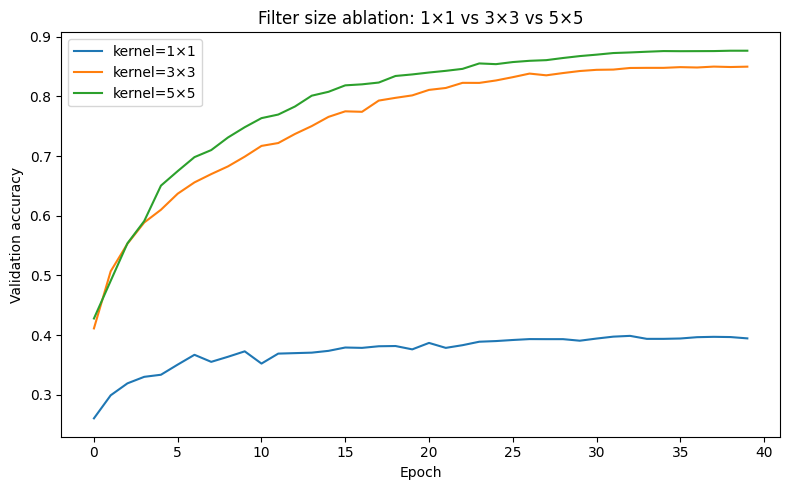

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))
for ks, result in kernel_results.items():
    ax.plot(result['val_accs'], label=f'kernel={ks}×{ks}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy')
ax.set_title('Filter size ablation: 1×1 vs 3×3 vs 5×5')
ax.legend()
plt.tight_layout()
plt.show()

**Observation and explanation**:

1. How did 1×1 perform? This is the empirical proof that spatial context matters.
2. Did 5×5 beat 3×3? Why or why not? (Think about both RF and parameter count.)
3. Why does almost all modern CNN design use 3×3 as the default filter size?

*(Your answers here)*

---
## Section 8 — Ablation: skip connections

This is the most important ablation. You will compare `ResNetStyle` to an identical architecture *without* skip connections to isolate exactly what residual connections contribute.

### ✏️ TASK 8.1 — Implement `ResNetStyle_NoSkip`

Copy the `ResNetStyle` architecture exactly, but replace each `ResidualBlock` with a plain block that has the same two conv layers but **no skip connection**.

**What changes**: the forward pass of the block simply returns `relu(bn2(conv2(relu(bn1(conv1(x))))))` — no addition with `x`.

You can implement this as a new `PlainBlock` class or just inline it.

In [26]:
class PlainBlock(nn.Module):
    """
    Two conv layers, NO skip connection. Used to ablate residual connections.
    Same architecture as ResidualBlock but without the skip addition.

    Args:
        channels (int)
        dropout  (float)
    """
    def __init__(self, channels, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE
        self.blocks=nn.Sequential(
            nn.Conv2d(channels,channels,3,1,1,bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Dropout2d(dropout),
            nn.Conv2d(channels,channels,3,1,1,bias=False),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        # YOUR CODE HERE — same as ResidualBlock but NO addition with x
        return F.relu(self.blocks(x))


class ResNetStyle_NoSkip(nn.Module):
    """
    Identical to ResNetStyle but using PlainBlock instead of ResidualBlock.
    """
    def __init__(self, num_classes=10, dropout=0.0):
        super().__init__()
        # YOUR CODE HERE — copy ResNetStyle and swap ResidualBlock → PlainBlock
        self.features = nn.Sequential(
            ConvBlock(3,64,kernel_size=3,stride=1,padding=1,dropout=dropout),

            PlainBlock(64,dropout=dropout),
            PlainBlock(64,dropout=dropout),
            ConvBlock(64,128,kernel_size=3,stride=2,padding=1,dropout=dropout),

            PlainBlock(128,dropout=dropout),
            PlainBlock(128,dropout=dropout),
            ConvBlock(128,256,kernel_size=3,stride=2,padding=1,dropout=dropout),

            PlainBlock(256,dropout=dropout),
            PlainBlock(256,dropout=dropout),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256,num_classes),
        )

    def forward(self, x):
        # YOUR CODE HERE
        x = self.features(x)
        return self.classifier(x)

Training ResNetStyle (WITH skip connections)...

Training ResNetStyle_NoSkip (WITHOUT skip connections)...
epoch 1 ,val loss is 1.6522, val acc is 0.3656
epoch 2 ,val loss is 1.4392, val acc is 0.4663
epoch 3 ,val loss is 1.2713, val acc is 0.5318
epoch 4 ,val loss is 1.1202, val acc is 0.5856
epoch 5 ,val loss is 1.0473, val acc is 0.6242
epoch 6 ,val loss is 0.9193, val acc is 0.6695
epoch 7 ,val loss is 0.8199, val acc is 0.7118
epoch 8 ,val loss is 0.7384, val acc is 0.7475
epoch 9 ,val loss is 0.7155, val acc is 0.752
epoch 10 ,val loss is 0.6226, val acc is 0.7829
epoch 11 ,val loss is 0.5986, val acc is 0.7927
epoch 12 ,val loss is 0.5597, val acc is 0.8098
epoch 13 ,val loss is 0.5358, val acc is 0.8149
epoch 14 ,val loss is 0.5092, val acc is 0.8297
epoch 15 ,val loss is 0.4715, val acc is 0.841
epoch 16 ,val loss is 0.4822, val acc is 0.8422
epoch 17 ,val loss is 0.4734, val acc is 0.8404
epoch 18 ,val loss is 0.4541, val acc is 0.8455
epoch 19 ,val loss is 0.4238, val acc is

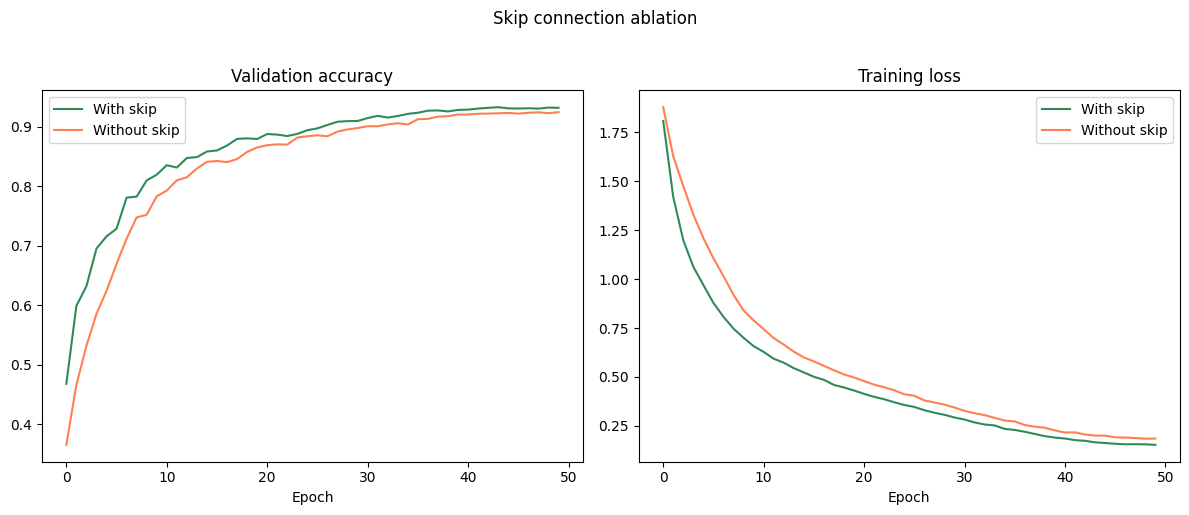

With skip:    best val acc = 93.26%
Without skip: best val acc = 92.43%


In [27]:
# ── Train both versions ────────────────────────────────────────────────────
print('Training ResNetStyle (WITH skip connections)...')
res_with = results['ResNet']   # reuse from Section 6 if already trained

print('\nTraining ResNetStyle_NoSkip (WITHOUT skip connections)...')
noskip_model  = ResNetStyle_NoSkip(dropout=0.2).to(DEVICE)
res_without   = train_model(noskip_model, train_loader, val_loader,
                             {**TRAIN_CONFIG, 'epochs': 50}, DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(res_with['val_accs'],    label='With skip',    color='seagreen')
axes[0].plot(res_without['val_accs'], label='Without skip', color='coral')
axes[0].set_title('Validation accuracy')
axes[0].legend()

axes[1].plot(res_with['train_losses'],    label='With skip',    color='seagreen')
axes[1].plot(res_without['train_losses'], label='Without skip', color='coral')
axes[1].set_title('Training loss')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('Epoch')

plt.suptitle('Skip connection ablation', y=1.02)
plt.tight_layout()
plt.show()

print(f'With skip:    best val acc = {res_with["best_val_acc"]:.2%}')
print(f'Without skip: best val acc = {res_without["best_val_acc"]:.2%}')

**Observation and explanation**:

1. What difference did the skip connections make? Was it accuracy, convergence speed, or training stability?
2. Look at the training loss curves — did the no-skip version show any instability (sudden spikes)?
3. In the original ResNet paper, residual connections had a dramatic effect at depths of 50+ layers. At our shallow depth (~10 layers), the effect is smaller. Why does the benefit of skip connections scale with depth?
4. What does a skip connection do to the gradient during backpropagation? (Hint: differentiate `output = F(x) + x` with respect to `x`.)

*(Your answers here)*

---
## Section 9 — Visualizing what the CNN learned

Understanding what a CNN has learned is as important as training it. This section gives you two visualization tools.

### ✏️ TASK 9.1 — Implement `visualize_feature_maps`

**What this does**: Given an image and a trained model, extract and visualize the activation maps after the first conv block. This shows you what low-level features the network detects.

**Arguments**:
- `model` (`nn.Module`): a trained CNN that has a `self.features` attribute (ShallowCNN or DeepCNN)
- `image` (`torch.Tensor`, shape `[3, 32, 32]`): a single normalized image from the dataset
- `n_filters` (`int`): how many filter outputs to show, default 16
- `device`

**Algorithm**:
```
1. Register a forward hook on the first Conv2d layer in model.features:
   hook saves the output activation in a list when the layer is called

2. Run a forward pass with the single image (add batch dim with unsqueeze(0))

3. Remove the hook

4. Extract the saved activation: shape [1, C, H, W]
   Squeeze batch dim → [C, H, W]

5. Plot the first n_filters channels in a grid
   Each subplot shows one channel as a grayscale image
```

**How to register a forward hook**:
```python
activations = []

def hook_fn(module, input, output):
    activations.append(output.detach().cpu())

handle = layer.register_forward_hook(hook_fn)
# ... run forward pass ...
handle.remove()   # always clean up!
```

In [28]:
def visualize_feature_maps(model, image, n_filters=16, device=DEVICE):
    """
    Visualize activation maps of the first Conv2d layer.

    Args:
        model    (nn.Module): trained CNN with self.features attribute
        image    (Tensor): single image, shape [3, 32, 32], normalized
        n_filters(int): number of filter maps to display
        device
    """
    # YOUR CODE HERE
    first_conv = None
    for layer in model.features:
        if isinstance(layer, nn.Conv2d):
            first_conv = layer
            break
        # if layer is a ConvBlock, look inside it
        for sublayer in layer.modules():
            if isinstance(sublayer, nn.Conv2d):
                first_conv = sublayer
                break
        if first_conv is not None:
            break

    # Step 2: register the hook
    activations = []
    def hook_fn(module, input, output):
        activations.append(output.detach().cpu())

    handle = first_conv.register_forward_hook(hook_fn)

    # Step 3: forward pass with the single image
    with torch.no_grad():
        image_batch = image.unsqueeze(0).to(device)  # [3,32,32] → [1,3,32,32]
        model(image_batch)

    # Step 4: remove the hook immediately after
    handle.remove()

    # Step 5: extract activation
    act = activations[0].squeeze(0)  # [1, C, H, W] → [C, H, W]
    n_filters = min(n_filters, act.shape[0])  # can't show more than we have

    # Step 6: plot
    cols = 4
    rows = (n_filters + cols - 1) // cols  # ceiling division
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    axes = axes.flatten()

    for i in range(n_filters):
        fmap = act[i].numpy()
        axes[i].imshow(fmap, cmap='viridis')
        axes[i].set_title(f'filter {i}')
        axes[i].axis('off')

    # hide any unused subplots
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')

    plt.suptitle('Feature maps — first Conv2d layer')
    plt.tight_layout()
    plt.show()

Visualizing feature maps for: airplane
Original image:


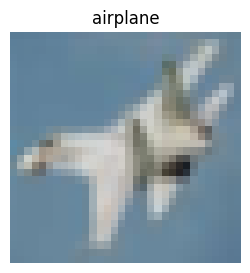

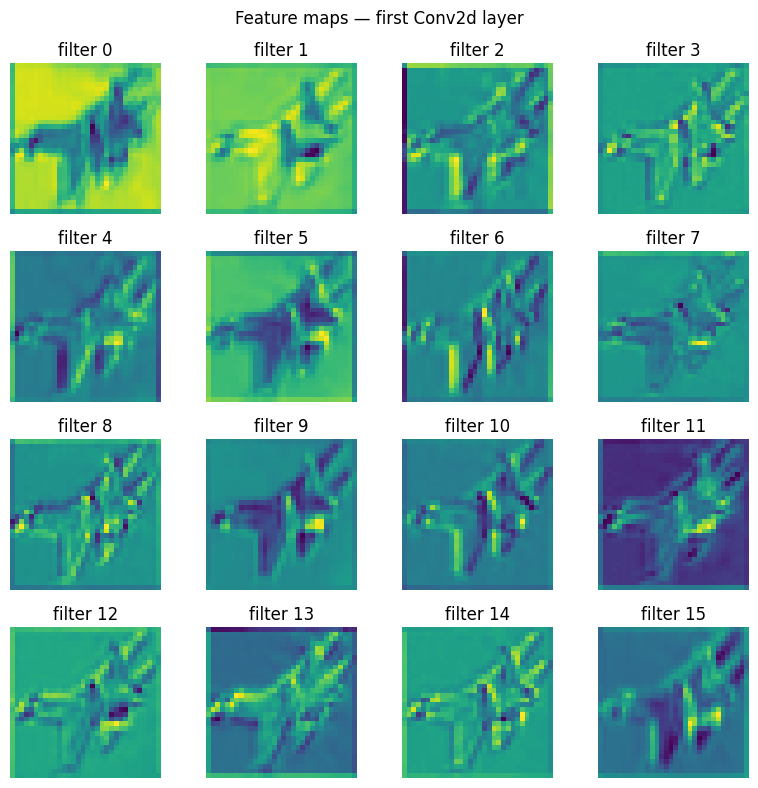

In [31]:
# ── Run the visualization ──────────────────────────────────────────────────
# Pick a clear image from the validation set
sample_img, sample_label = val_dataset[10]

print(f'Visualizing feature maps for: {CIFAR10_CLASSES[sample_label]}')
print(f'Original image:')
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(denormalize(sample_img).permute(1, 2, 0).numpy())
ax.set_title(CIFAR10_CLASSES[sample_label])
ax.axis('off')
plt.show()

# Use the trained DeepCNN
best_deep_model = results['Deep']['model'].to(DEVICE)
visualize_feature_maps(best_deep_model, sample_img, n_filters=16, device=DEVICE)

**Observation**: Look at the 16 feature maps. Can you identify what each filter is detecting? Common low-level features in the first layer include edges (horizontal, vertical, diagonal), color blobs, and textures. Do you see any of these?

*(Your observations here)*

---
## Section 10 — Confusion matrix and error analysis

Accuracy alone doesn't tell you *where* your model fails. A confusion matrix shows you which classes get confused with each other — this often reveals meaningful patterns.

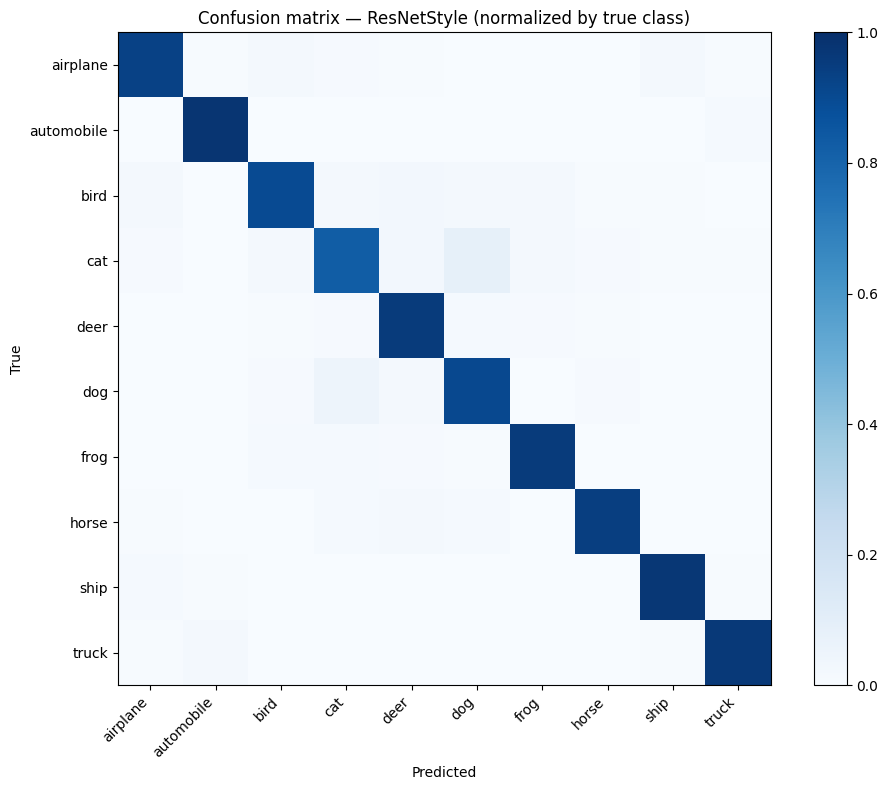


Per-class accuracy:
  airplane    : 93.0%
  automobile  : 98.0%
  bird        : 89.5%
  cat         : 82.7%
  deer        : 95.6%
  dog         : 90.5%
  frog        : 95.7%
  horse       : 94.4%
  ship        : 96.9%
  truck       : 96.3%


In [34]:
# ── TASK 10.1 — Compute and plot confusion matrix ─────────────────────────
# This cell is mostly given to you — but you must fill in the prediction loop.

def get_all_predictions(model, loader, device):
    """
    Run model on the full loader and return all predictions and true labels.

    Returns:
        preds  (np.ndarray): predicted class indices, shape [N]
        labels (np.ndarray): true class indices, shape [N]
    """
    # YOUR CODE HERE
    # Hint: no_grad, eval mode, loop over loader, collect argmax predictions
    preds=[]
    labels=[]
    model.eval()
    with torch.no_grad():
      for X_batch,y_batch in loader:
        X_batch,y_batch = X_batch.to(device),y_batch.to(device)
        labels.append(y_batch)
        logits = model(X_batch)
        preds.append(logits.argmax(dim=1))
    preds = torch.cat(preds).cpu().numpy()
    labels = torch.cat(labels).cpu().numpy()
    return preds,labels


best_model = results['ResNet']['model'].to(DEVICE)
preds, labels = get_all_predictions(best_model, val_loader, DEVICE)

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(labels, preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_normalized, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha='right')
ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion matrix — ResNetStyle (normalized by true class)')
plt.tight_layout()
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, cls in enumerate(CIFAR10_CLASSES):
    print(f'  {cls:12s}: {cm_normalized[i, i]:.1%}')

**Observation and explanation**:

1. Which two classes are most frequently confused? Does this make intuitive sense (e.g. cat vs dog, automobile vs truck)?<br>
cats and dogs
2. Which class has the highest accuracy? Why might it be easier to classify?<br>
automobile
3. What does this error analysis tell you about the limits of visual features for CIFAR-10?

*(Your answers here)*

---
## Section 11 — Final reflection

Answer all of these. These are real interview and research discussion questions.

1. **Architecture design from scratch**: If someone gave you a new image classification task on 128×128 images with 50 classes, how would you design your CNN? Walk through each decision: number of stages, channels per stage, when to downsample, head design.

2. **Inductive bias**: A CNN enforces *translation equivariance* — a feature detector in the top-left of the image is the same detector in the bottom-right. Why is this useful for images? What type of data would this inductive bias *not* be appropriate for?

3. **BatchNorm**: You used BatchNorm in every ConvBlock. What would happen if you removed it entirely? Try it empirically on ShallowCNN if you have time — does training still converge?

4. **Data augmentation**: You used `RandomHorizontalFlip` and `RandomCrop`. What would happen to val accuracy if you removed augmentation? Why do these specific augmentations help?

5. **Connecting to LLMs**: The transformer architecture used in LLMs also has skip connections (in each attention block and FFN block). Based on what you observed in Section 8, why are those skip connections critical for training very deep transformers (e.g. GPT-4 with 100+ layers)?

*(Your answers here)*

---
## Bonus — Learning rate finder

Instead of guessing a learning rate, you can *find* it empirically. The **LR range test** (Smith 2015) sweeps LR from very small to very large over one epoch and plots loss vs LR. The optimal LR is just before the loss starts rising steeply.

### ✏️ BONUS TASK — Implement `lr_finder`

**Algorithm**:
```
start_lr = 1e-7, end_lr = 10.0, num_steps = 100
lr_multiplier = (end_lr / start_lr) ** (1 / num_steps)

set optimizer LR to start_lr
smoothed_loss = 0.0, beta = 0.98

for step, (x, y) in enumerate(loader):
    if step >= num_steps: break
    current_lr = start_lr * lr_multiplier^step
    set optimizer LR to current_lr

    forward pass, compute loss
    smoothed_loss = beta * smoothed_loss + (1 - beta) * loss.item()
    debiased_loss = smoothed_loss / (1 - beta^(step+1))

    if step > 10 and debiased_loss > 4 * best_loss: break  # diverged
    if debiased_loss < best_loss or step == 0: best_loss = debiased_loss

    record (current_lr, debiased_loss)
    backward + optimizer step

plot log(lr) vs loss
optimal LR is where the slope is steepest downward
```

In [ ]:
def lr_finder(model, loader, device, start_lr=1e-7, end_lr=10.0, num_steps=100):
    """
    LR range test. Plots loss vs learning rate.
    Optimal LR is just before the steepest descent.

    Note: this mutates model weights — call on a fresh model.
    """
    # YOUR CODE HERE
    raise NotImplementedError


# Test it
fresh_model = ResNetStyle().to(DEVICE)
lr_finder(fresh_model, train_loader, DEVICE)